# K-Moda MMM — Fase 5: Evaluación del Modelo y Atribución

**Objetivo:** Evaluar el rendimiento del modelo ElasticNet entrenado, analizar residuos, descomponer las ventas entre Core Base y contribución de medios, y construir la tabla completa de atribución con mROI por canal.

**Inputs:**
- `data/df_model.parquet` — features + variable dependiente
- `data/df_inversion_clean.parquet` — inversión real por canal
- `models/modelo_final.pkl` — modelo ElasticNet entrenado
- `models/scaler.pkl` — StandardScaler ajustado sobre train
- `models/modelo_meta.pkl` — hiperparámetros, métricas, betas

**Outputs:**
- `outputs/tabla_atribucion.csv`
- Gráficos en `img/`

## Bloque 0 — Configuración e imports

In [32]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as sp_stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from sklearn.metrics import r2_score, mean_absolute_percentage_error

warnings.filterwarnings('ignore')

# ── Rutas ────────────────────────────────────────────────────────────────────
PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR   = os.path.join(PROJECT_DIR, 'models')
IMG_DIR     = os.path.join(PROJECT_DIR, 'img')
OUT_DIR     = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Paleta ───────────────────────────────────────────────────────────────────
CREAM   = '#FAF7F2'
BLACK   = '#1A1A1A'
DARK    = '#2D2D2D'
GOLD    = '#C9A84C'
TEAL    = '#2E7D7B'
CORAL   = '#D4614B'
BLUE    = '#3A5F8A'
PURPLE  = '#6B4E8A'
GREEN   = '#4A7C59'
ORANGE  = '#C97B3A'
PINK    = '#B05070'

CANAL_COLORS = {
    'Paid Search':  GOLD,
    'Social Paid':  CORAL,
    'Video Online': TEAL,
    'Display':      BLUE,
    'Email CRM':    PURPLE,
    'Radio Local':  GREEN,
    'Exterior':     ORANGE,
    'Prensa':       PINK,
}

CANALES = list(CANAL_COLORS.keys())
ADSTOCK_MAP = {
    'Paid Search':  'adstock_Paid_Search',
    'Social Paid':  'adstock_Social_Paid',
    'Video Online': 'adstock_Video_Online',
    'Display':      'adstock_Display',
    'Email CRM':    'adstock_Email_CRM',
    'Radio Local':  'adstock_Radio_Local',
    'Exterior':     'adstock_Exterior',
    'Prensa':       'adstock_Prensa',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.facecolor':    CREAM,
    'figure.facecolor':  CREAM,
    'axes.edgecolor':    BLACK,
    'axes.labelcolor':   BLACK,
    'xtick.color':       BLACK,
    'ytick.color':       BLACK,
    'text.color':        BLACK,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

# ── Versioning de imágenes ───────────────────────────────────────────────────
_img_counters = {}
def guardar_img(nombre, fig=None, dpi=150, **kwargs):
    if fig is None:
        fig = plt.gcf()
    n = _img_counters.get(nombre, 1)
    path = os.path.join(IMG_DIR, f'{nombre}_v{n:03d}.png')
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor(), **kwargs)
    _img_counters[nombre] = n + 1
    print(f'  Guardada: img/{nombre}_v{n:03d}.png')

print('✓ Configuración lista')
print(f'  IMG_DIR : {IMG_DIR}')
print(f'  OUT_DIR : {OUT_DIR}')

✓ Configuración lista
  IMG_DIR : /Users/ruben/Desktop/3º INGENIERÍA MATEMÁTICA/2ºCUATRI/INTELIGENCIA ARTIFICIAL/ENTREGA-MARKETING/ENTREGA/img
  OUT_DIR : /Users/ruben/Desktop/3º INGENIERÍA MATEMÁTICA/2ºCUATRI/INTELIGENCIA ARTIFICIAL/ENTREGA-MARKETING/ENTREGA/outputs


## Bloque 1 — Carga de artefactos

In [33]:
# ── Datos ────────────────────────────────────────────────────────────────────
df_model = pd.read_parquet(os.path.join(DATA_DIR, 'df_model.parquet'))
df_inv   = pd.read_parquet(os.path.join(DATA_DIR, 'df_inversion_clean.parquet'))

df_model = df_model.sort_values('semana_dt').reset_index(drop=True)
df_model['semana_dt'] = pd.to_datetime(df_model['semana_dt'])
# Replicar log_semana de 04_modeling (no se persiste en parquet)
df_model['log_semana'] = np.log1p(np.arange(len(df_model)))
df_inv['semana_dt']   = pd.to_datetime(df_inv['semana_dt'])

# ── Modelos ──────────────────────────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, 'modelo_final.pkl'), 'rb') as f:
    modelo = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'modelo_meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

# ── Extraer metadatos ────────────────────────────────────────────────────────
FEATURE_COLS     = meta['feature_cols']
ADSTOCK_COLS     = meta['adstock_cols']
CORTE_TEST       = pd.Timestamp(meta['corte_test'])
ALPHA_OPT        = meta['alpha_optimo']
L1_OPT           = meta['l1_ratio_optimo']
MAPE_TRAIN       = meta['mape_train']
MAPE_TEST        = meta['mape_test']
R2_TRAIN         = meta['r2_train']
R2_TEST          = meta['r2_test']
BETAS            = meta['beta_original']          # dict {feature: beta}
CANALES_ACTIVOS  = meta['canales_activos']
CANALES_PURGADOS = meta['canales_purgados']

# ── Splits ───────────────────────────────────────────────────────────────────
df_train = df_model[df_model['semana_dt'] <  CORTE_TEST].copy()
df_test  = df_model[df_model['semana_dt'] >= CORTE_TEST].copy()

X_train = scaler.transform(df_train[FEATURE_COLS])
X_test  = scaler.transform(df_test[FEATURE_COLS])
y_train = df_train['Yt'].values
y_test  = df_test['Yt'].values

y_pred_train = modelo.predict(X_train)
y_pred_test  = modelo.predict(X_test)

residuos_train = y_train - y_pred_train
residuos_test  = y_test  - y_pred_test

print('✓ Artefactos cargados')
print(f'  Train: {len(df_train)} semanas  |  Test: {len(df_test)} semanas')
print(f'  α={ALPHA_OPT}  l1_ratio={L1_OPT}')
print(f'  MAPE Train: {MAPE_TRAIN:.2f}%  |  MAPE Test: {MAPE_TEST:.2f}%')
print(f'  R²   Train: {R2_TRAIN:.4f}  |  R²   Test: {R2_TEST:.4f}')
print(f'  Canales activos:  {CANALES_ACTIVOS}')
print(f'  Canales purgados: {CANALES_PURGADOS}')

✓ Artefactos cargados
  Train: 208 semanas  |  Test: 53 semanas
  α=0.2  l1_ratio=0.01
  MAPE Train: 10.71%  |  MAPE Test: 16.47%
  R²   Train: 0.7197  |  R²   Test: -1.9824
  Canales activos:  ['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Email CRM', 'Radio Local', 'Exterior', 'Prensa']
  Canales purgados: []


## Bloque 2 — Predicho vs Real

Comparación temporal y scatter entre ventas reales y predicciones del modelo sobre el set de test 2024.

  Guardada: img/real_vs_predicho_serie_v001.png


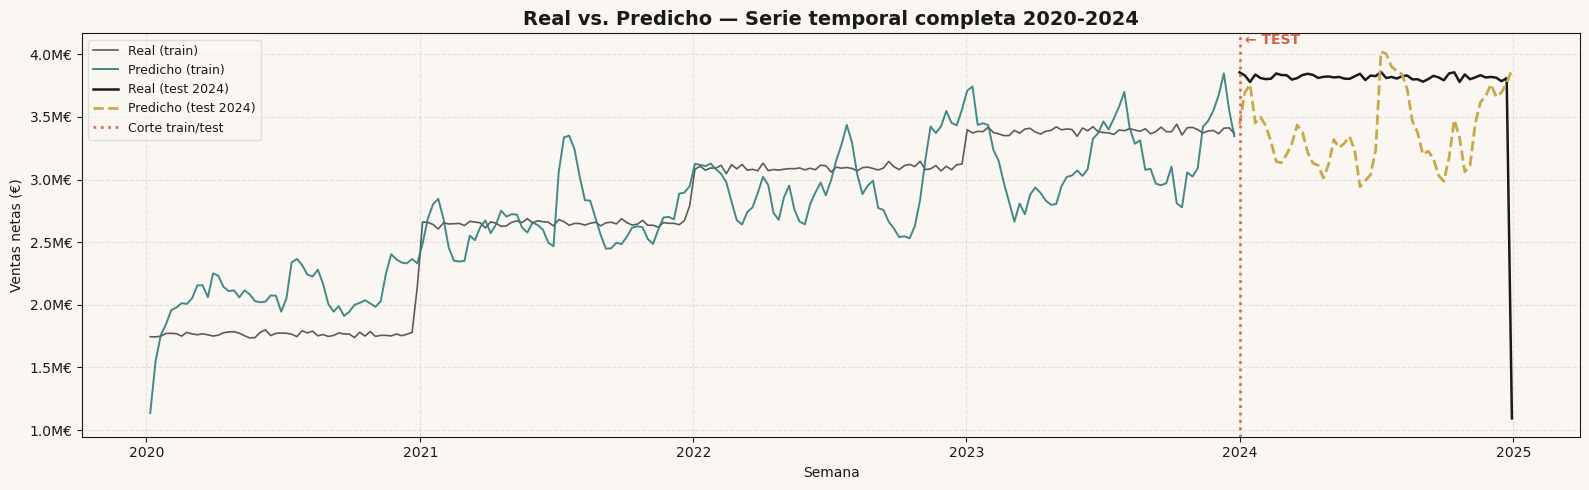

In [34]:
# ── 2.1 Serie temporal: real vs predicho (completa train + test) ─────────────
fechas_train = df_train['semana_dt'].values
fechas_test  = df_test['semana_dt'].values

fig, ax = plt.subplots(figsize=(16, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.plot(fechas_train, y_train,      color=BLACK, linewidth=1.2, alpha=0.7, label='Real (train)')
ax.plot(fechas_train, y_pred_train, color=TEAL,  linewidth=1.4, alpha=0.9, label='Predicho (train)')
ax.plot(fechas_test,  y_test,       color=BLACK, linewidth=1.8, label='Real (test 2024)')
ax.plot(fechas_test,  y_pred_test,  color=GOLD,  linewidth=2.0, linestyle='--', label='Predicho (test 2024)')

ax.axvline(CORTE_TEST, color=CORAL, linewidth=2, linestyle=':', alpha=0.9, label='Corte train/test')
ax.text(CORTE_TEST, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else y_train.max(),
        ' ← TEST', color=CORAL, fontsize=10, va='top', fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.set_title('Real vs. Predicho — Serie temporal completa 2020-2024', fontsize=14, fontweight='bold', color=BLACK)
ax.set_xlabel('Semana')
ax.set_ylabel('Ventas netas (€)')
ax.legend(fontsize=9, framealpha=0.6)
fig.tight_layout()
guardar_img('real_vs_predicho_serie')
plt.show()

  Guardada: img/real_vs_predicho_test_zoom_v001.png


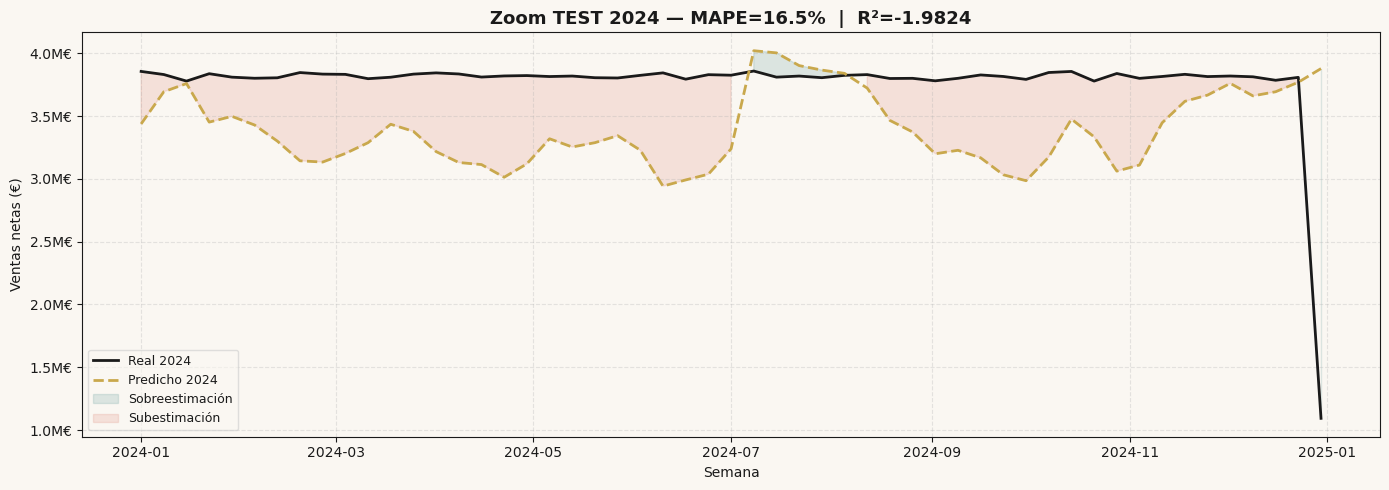

In [35]:
# ── 2.2 Serie temporal: zoom en TEST 2024 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.plot(fechas_test, y_test,      color=BLACK, linewidth=2,   label='Real 2024')
ax.plot(fechas_test, y_pred_test, color=GOLD,  linewidth=2, linestyle='--', label='Predicho 2024')
ax.fill_between(fechas_test, y_test, y_pred_test,
                where=(y_pred_test >= y_test), alpha=0.15, color=TEAL,  label='Sobreestimación')
ax.fill_between(fechas_test, y_test, y_pred_test,
                where=(y_pred_test <  y_test), alpha=0.15, color=CORAL, label='Subestimación')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.set_title(f'Zoom TEST 2024 — MAPE={MAPE_TEST:.1f}%  |  R²={R2_TEST:.4f}',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_xlabel('Semana')
ax.set_ylabel('Ventas netas (€)')
ax.legend(fontsize=9, framealpha=0.6)
fig.tight_layout()
guardar_img('real_vs_predicho_test_zoom')
plt.show()

  Guardada: img/scatter_real_predicho_test_v001.png


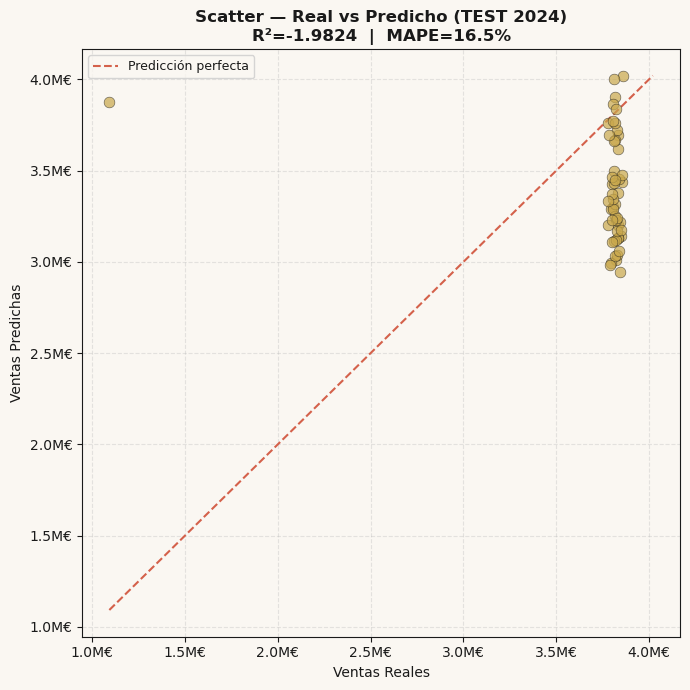

In [36]:
# ── 2.3 Scatter Real vs Predicho (test) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.scatter(y_test, y_pred_test, color=GOLD, edgecolors=BLACK, linewidth=0.4,
           alpha=0.7, s=60, zorder=3)

# Línea perfecta
mn = min(y_test.min(), y_pred_test.min())
mx = max(y_test.max(), y_pred_test.max())
ax.plot([mn, mx], [mn, mx], color=CORAL, linewidth=1.5, linestyle='--', label='Predicción perfecta')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.set_title(f'Scatter — Real vs Predicho (TEST 2024)\nR²={R2_TEST:.4f}  |  MAPE={MAPE_TEST:.1f}%',
             fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Ventas Reales')
ax.set_ylabel('Ventas Predichas')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('scatter_real_predicho_test')
plt.show()

  Guardada: img/ape_por_semana_test_v001.png


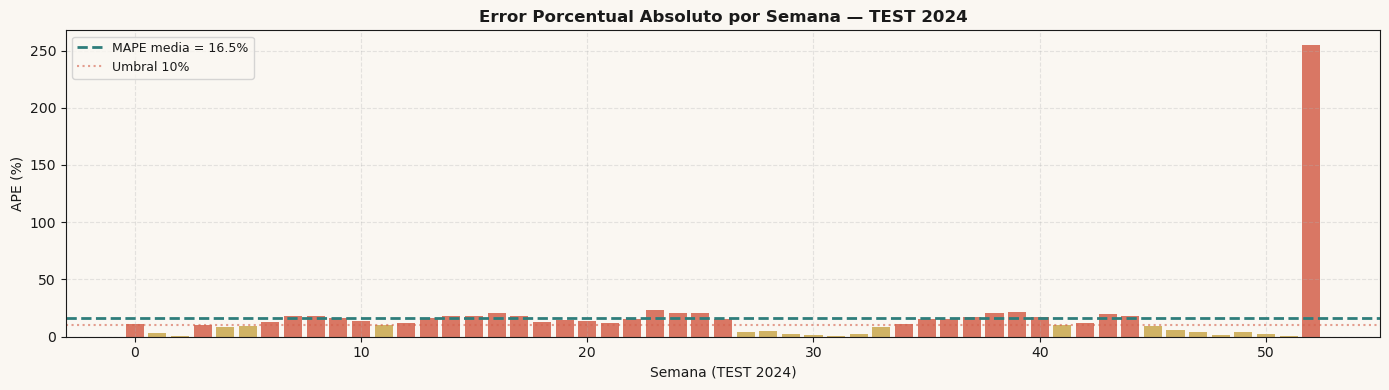

MAPE TEST: 16.47%
Semanas con APE > 10%: 33 de 53


In [37]:
# ── 2.4 APE (Absolute Percentage Error) por semana — test ───────────────────
ape_test = np.abs((y_test - y_pred_test) / y_test) * 100

fig, ax = plt.subplots(figsize=(14, 4), facecolor=CREAM)
ax.set_facecolor(CREAM)

colores_ape = [CORAL if v > 10 else GOLD for v in ape_test]
ax.bar(range(len(ape_test)), ape_test, color=colores_ape, edgecolor='none', alpha=0.85)
ax.axhline(ape_test.mean(), color=TEAL, linewidth=2, linestyle='--',
           label=f'MAPE media = {ape_test.mean():.1f}%')
ax.axhline(10, color=CORAL, linewidth=1.5, linestyle=':', alpha=0.6, label='Umbral 10%')

ax.set_title('Error Porcentual Absoluto por Semana — TEST 2024', fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Semana (TEST 2024)')
ax.set_ylabel('APE (%)')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('ape_por_semana_test')
plt.show()

print(f'MAPE TEST: {ape_test.mean():.2f}%')
print(f'Semanas con APE > 10%: {(ape_test > 10).sum()} de {len(ape_test)}')

## Bloque 3 — Análisis de Residuos

Evaluación de los supuestos del modelo lineal: normalidad, autocorrelación y homocedasticidad.

  Guardada: img/residuos_distribucion_train_v001.png


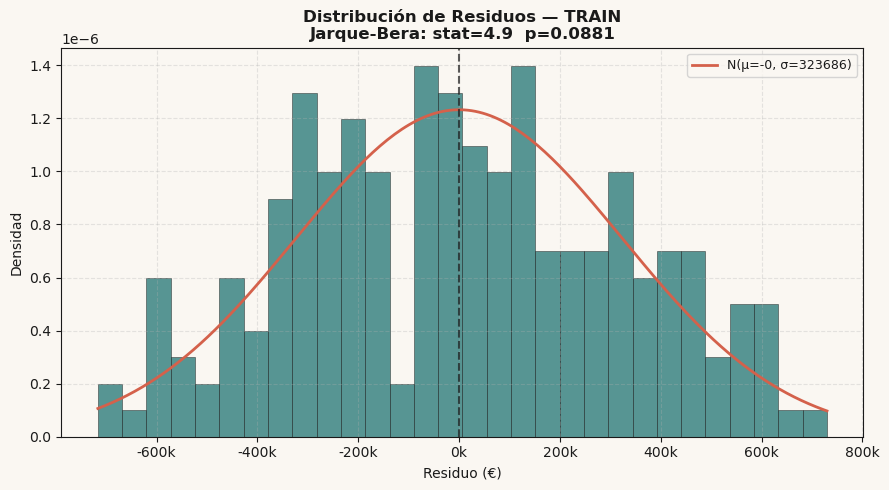

In [38]:
# ── 3.1 Distribución de residuos — train ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.hist(residuos_train, bins=30, color=TEAL, edgecolor=BLACK, linewidth=0.4, alpha=0.8, density=True)

# Curva normal teórica
xr = np.linspace(residuos_train.min(), residuos_train.max(), 200)
mu, sigma = residuos_train.mean(), residuos_train.std()
ax.plot(xr, sp_stats.norm.pdf(xr, mu, sigma), color=CORAL, linewidth=2, label=f'N(μ={mu:.0f}, σ={sigma:.0f})')
ax.axvline(0, color=BLACK, linewidth=1.5, linestyle='--', alpha=0.7)

jb = sp_stats.jarque_bera(residuos_train)
ax.set_title(f'Distribución de Residuos — TRAIN\nJarque-Bera: stat={jb.statistic:.1f}  p={jb.pvalue:.4f}',
             fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Residuo (€)')
ax.set_ylabel('Densidad')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('residuos_distribucion_train')
plt.show()

  Guardada: img/residuos_distribucion_test_v001.png


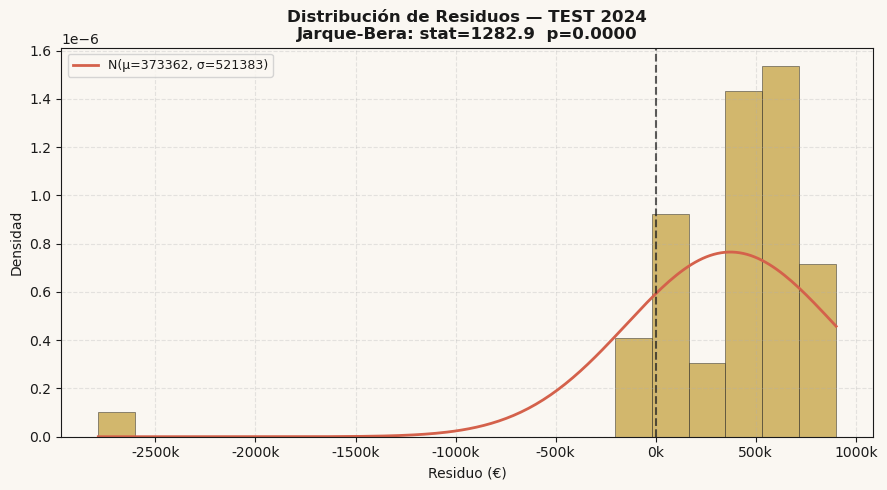

In [39]:
# ── 3.2 Distribución de residuos — test ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.hist(residuos_test, bins=20, color=GOLD, edgecolor=BLACK, linewidth=0.4, alpha=0.8, density=True)

xr = np.linspace(residuos_test.min(), residuos_test.max(), 200)
mu_t, sigma_t = residuos_test.mean(), residuos_test.std()
ax.plot(xr, sp_stats.norm.pdf(xr, mu_t, sigma_t), color=CORAL, linewidth=2,
        label=f'N(μ={mu_t:.0f}, σ={sigma_t:.0f})')
ax.axvline(0, color=BLACK, linewidth=1.5, linestyle='--', alpha=0.7)

jb_t = sp_stats.jarque_bera(residuos_test)
ax.set_title(f'Distribución de Residuos — TEST 2024\nJarque-Bera: stat={jb_t.statistic:.1f}  p={jb_t.pvalue:.4f}',
             fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Residuo (€)')
ax.set_ylabel('Densidad')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('residuos_distribucion_test')
plt.show()

  Guardada: img/qqplot_residuos_train_v001.png


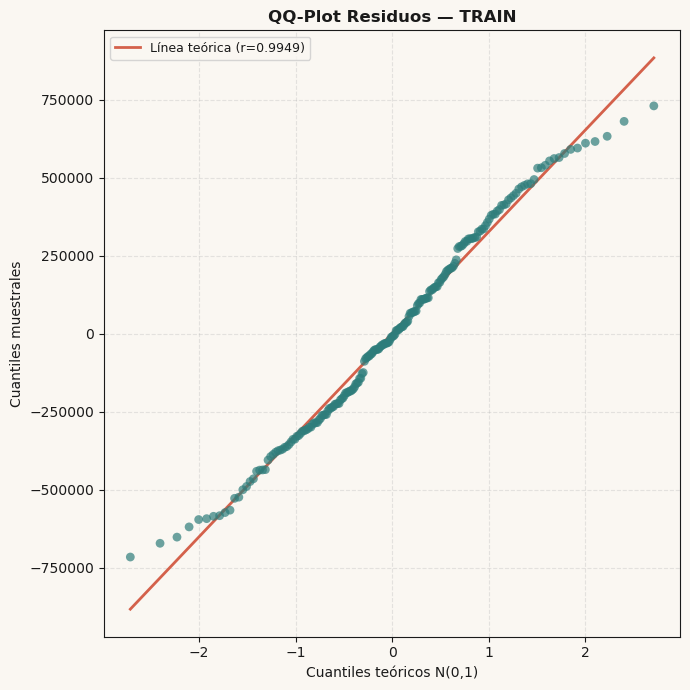

In [40]:
# ── 3.3 QQ-Plot residuos train ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7), facecolor=CREAM)
ax.set_facecolor(CREAM)

(osm, osr), (slope, intercept, r) = sp_stats.probplot(residuos_train, dist='norm')
ax.scatter(osm, osr, color=TEAL, alpha=0.7, s=40, edgecolors='none', zorder=3)
ax.plot(osm, slope * np.array(osm) + intercept, color=CORAL, linewidth=2, label=f'Línea teórica (r={r:.4f})')

ax.set_title('QQ-Plot Residuos — TRAIN', fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Cuantiles teóricos N(0,1)')
ax.set_ylabel('Cuantiles muestrales')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('qqplot_residuos_train')
plt.show()

  Guardada: img/residuos_vs_predicho_train_v001.png


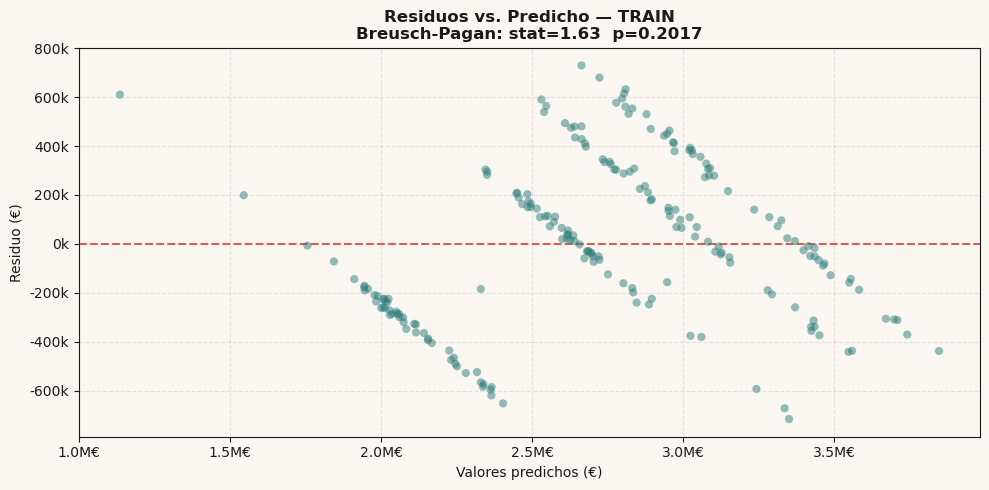

In [41]:
# ── 3.4 Residuos vs Predicho (homocedasticidad) — train ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.scatter(y_pred_train, residuos_train, color=TEAL, alpha=0.5, s=35, edgecolors='none', zorder=3)
ax.axhline(0, color=CORAL, linewidth=1.5, linestyle='--')

# Test Breusch-Pagan
try:
    X_ols = add_constant(y_pred_train)
    res_ols = OLS(residuos_train**2, X_ols).fit()
    bp_stat, bp_p, _, _ = het_breuschpagan(residuos_train, X_ols)
    bp_txt = f'Breusch-Pagan: stat={bp_stat:.2f}  p={bp_p:.4f}'
except Exception:
    bp_txt = ''

ax.set_title(f'Residuos vs. Predicho — TRAIN\n{bp_txt}', fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Valores predichos (€)')
ax.set_ylabel('Residuo (€)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
fig.tight_layout()
guardar_img('residuos_vs_predicho_train')
plt.show()

  Guardada: img/acf_residuos_train_v001.png


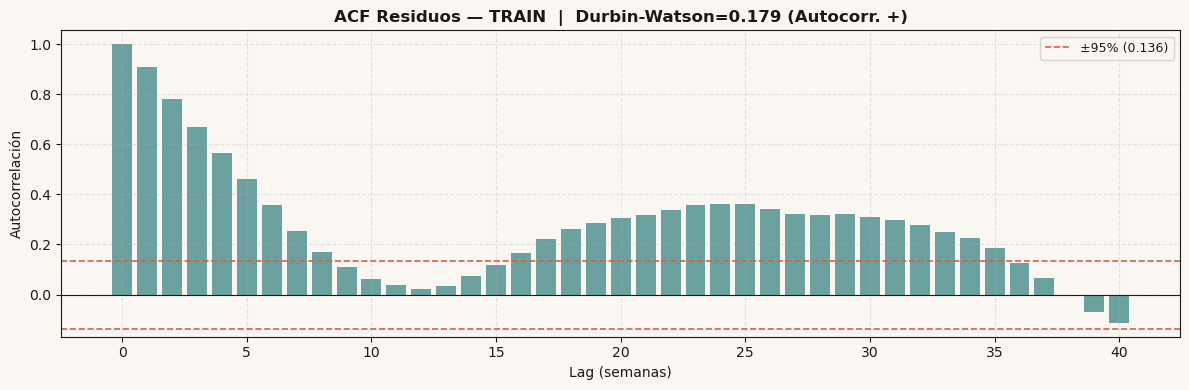

Durbin-Watson (train): 0.179  →  Autocorr. +


In [42]:
# ── 3.5 Autocorrelación de residuos — train (Durbin-Watson) ─────────────────
dw_stat = durbin_watson(residuos_train)

lags_max = min(40, len(residuos_train) // 2)
acf_vals = [np.corrcoef(residuos_train[:-k], residuos_train[k:])[0, 1] if k > 0 else 1.0
            for k in range(lags_max + 1)]
conf_bound = 1.96 / np.sqrt(len(residuos_train))

fig, ax = plt.subplots(figsize=(12, 4), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.bar(range(len(acf_vals)), acf_vals, color=TEAL, alpha=0.7, edgecolor='none')
ax.axhline( conf_bound, color=CORAL, linestyle='--', linewidth=1.2, label=f'±95% ({conf_bound:.3f})')
ax.axhline(-conf_bound, color=CORAL, linestyle='--', linewidth=1.2)
ax.axhline(0, color=BLACK, linewidth=0.8)

dw_interp = 'Sin autocorr.' if 1.5 < dw_stat < 2.5 else ('Autocorr. +' if dw_stat < 1.5 else 'Autocorr. -')
ax.set_title(f'ACF Residuos — TRAIN  |  Durbin-Watson={dw_stat:.3f} ({dw_interp})',
             fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Lag (semanas)')
ax.set_ylabel('Autocorrelación')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('acf_residuos_train')
plt.show()

print(f'Durbin-Watson (train): {dw_stat:.3f}  →  {dw_interp}')

  Guardada: img/residuos_en_tiempo_v001.png


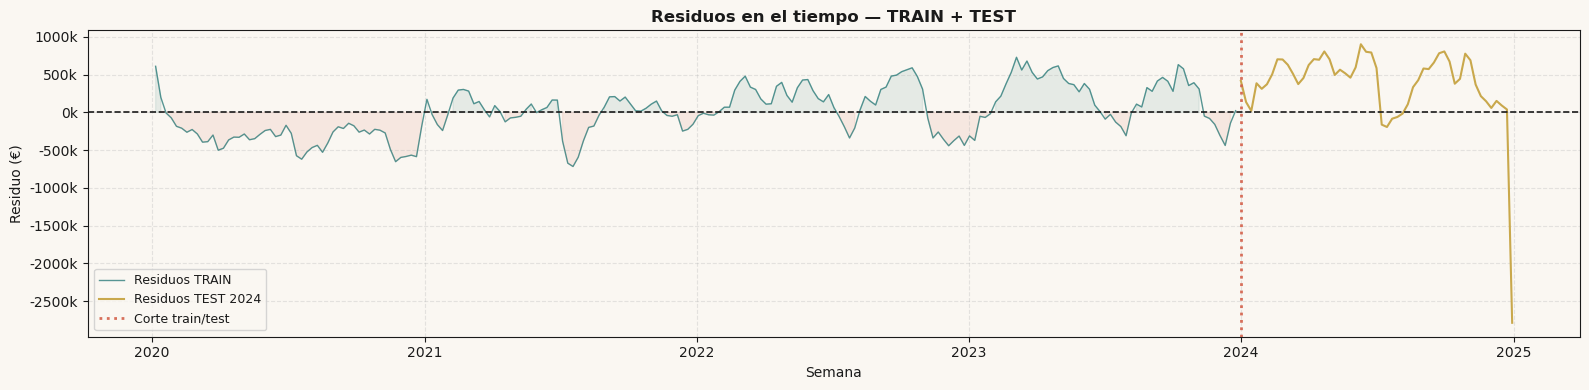

In [43]:
# ── 3.6 Residuos en el tiempo — train + test ─────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.plot(fechas_train, residuos_train, color=TEAL,  linewidth=1.0, alpha=0.8, label='Residuos TRAIN')
ax.plot(fechas_test,  residuos_test,  color=GOLD,  linewidth=1.5, label='Residuos TEST 2024')
ax.axhline(0, color=BLACK, linewidth=1.2, linestyle='--')
ax.axvline(CORTE_TEST, color=CORAL, linewidth=2, linestyle=':', alpha=0.9, label='Corte train/test')
ax.fill_between(fechas_train, residuos_train, 0, where=(residuos_train > 0),
                alpha=0.10, color=TEAL)
ax.fill_between(fechas_train, residuos_train, 0, where=(residuos_train < 0),
                alpha=0.10, color=CORAL)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_title('Residuos en el tiempo — TRAIN + TEST', fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Semana')
ax.set_ylabel('Residuo (€)')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('residuos_en_tiempo')
plt.show()

In [44]:
# ── 3.7 Tabla resumen diagnóstico ────────────────────────────────────────────
dw_test = durbin_watson(residuos_test)
jb_train = sp_stats.jarque_bera(residuos_train)
jb_test  = sp_stats.jarque_bera(residuos_test)

print('═' * 55)
print('  DIAGNÓSTICO ESTADÍSTICO DEL MODELO')
print('═' * 55)
print(f'  Métrica            TRAIN          TEST')
print(f'  ─────────────────────────────────────')
print(f'  R²                 {R2_TRAIN:>8.4f}      {R2_TEST:>8.4f}')
print(f'  MAPE               {MAPE_TRAIN:>7.2f}%      {MAPE_TEST:>7.2f}%')
print(f'  Residuo medio      {residuos_train.mean():>10.0f}€    {residuos_test.mean():>10.0f}€')
print(f'  Residuo std        {residuos_train.std():>10.0f}€    {residuos_test.std():>10.0f}€')
print(f'  Durbin-Watson      {dw_stat:>8.3f}      {dw_test:>8.3f}')
print(f'  Jarque-Bera p      {jb_train.pvalue:>8.4f}      {jb_test.pvalue:>8.4f}')
print('═' * 55)

═══════════════════════════════════════════════════════
  DIAGNÓSTICO ESTADÍSTICO DEL MODELO
═══════════════════════════════════════════════════════
  Métrica            TRAIN          TEST
  ─────────────────────────────────────
  R²                   0.7197       -1.9824
  MAPE                 10.71%        16.47%
  Residuo medio              -0€        373362€
  Residuo std            323686€        521383€
  Durbin-Watson         0.179         0.444
  Jarque-Bera p        0.0881        0.0000
═══════════════════════════════════════════════════════


## Bloque 4 — Coeficientes Beta

Visualización de los coeficientes desescalados del modelo ElasticNet: qué canales contribuyen y en qué magnitud.

  Guardada: img/betas_canales_medios_v001.png


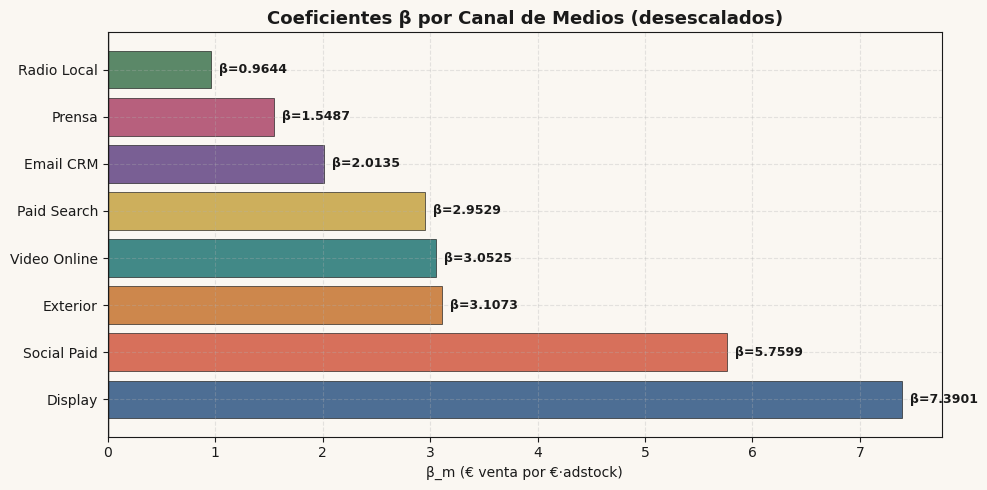

In [45]:
# ── 4.1 Betas de los 8 canales de medios ────────────────────────────────────
betas_canales = {canal: BETAS.get(ADSTOCK_MAP[canal], 0.0) for canal in CANALES}

canales_ord = sorted(betas_canales.keys(), key=lambda c: betas_canales[c], reverse=True)
valores_ord = [betas_canales[c] for c in canales_ord]
colores_ord = [CANAL_COLORS[c] if betas_canales[c] > 0 else '#AAAAAA' for c in canales_ord]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

bars = ax.barh(canales_ord, valores_ord, color=colores_ord, edgecolor=BLACK, linewidth=0.5, alpha=0.9)
for bar, val in zip(bars, valores_ord):
    if val > 0:
        ax.text(val + max(valores_ord)*0.01, bar.get_y() + bar.get_height()/2,
                f'β={val:.4f}', va='center', fontsize=9, color=BLACK, fontweight='bold')
    else:
        ax.text(max(valores_ord)*0.01, bar.get_y() + bar.get_height()/2,
                'Purgado (β=0)', va='center', fontsize=8, color='#888888', style='italic')

ax.axvline(0, color=BLACK, linewidth=1)
ax.set_title('Coeficientes β por Canal de Medios (desescalados)',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_xlabel('β_m (€ venta por €·adstock)')
fig.tight_layout()
guardar_img('betas_canales_medios')
plt.show()

  Guardada: img/betas_exogenas_v001.png


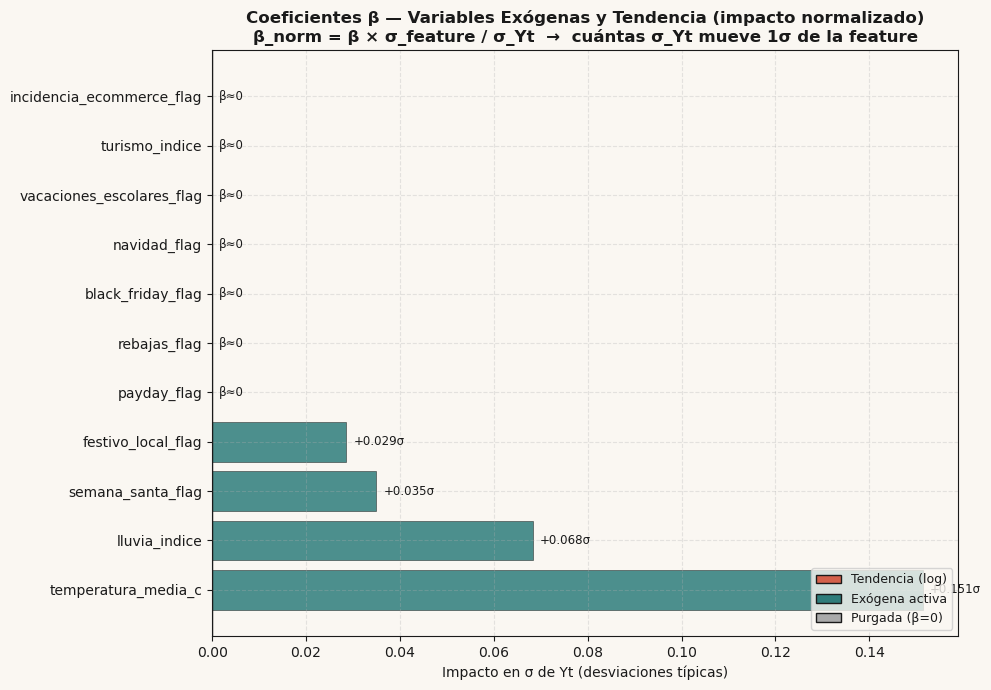

In [46]:
# ── 4.2 Betas de variables exógenas + tendencia ─────────────────────────────
# Calcular impacto normalizado β_norm = β × σ_feature / σ_Yt
# (mide cuántas σ_Yt se mueven cuando la feature sube 1σ)
exog_cols = [c for c in FEATURE_COLS if not c.startswith('adstock_')]
sigma_y   = df_model['Yt'].std()
sigma_f   = {c: df_model[c].std() for c in exog_cols}
betas_norm = {c: BETAS.get(c, 0.0) * sigma_f[c] / sigma_y for c in exog_cols}
betas_norm_sorted = dict(sorted(betas_norm.items(), key=lambda x: x[1], reverse=True))

labels_n = list(betas_norm_sorted.keys())
vals_n   = list(betas_norm_sorted.values())
cols_n   = [CORAL if c == 'log_semana' else (TEAL if v > 0 else '#AAAAAA')
            for c, v in zip(labels_n, vals_n)]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=CREAM)
ax.set_facecolor(CREAM)

bars = ax.barh(labels_n, vals_n, color=cols_n, edgecolor=BLACK, linewidth=0.4, alpha=0.85)
for bar, val in zip(bars, vals_n):
    offset = max(abs(v) for v in vals_n) * 0.01
    ax.text(val + (offset if val >= 0 else -offset),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}σ' if abs(val) > 1e-4 else 'β≈0',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=8.5, color=BLACK)

ax.axvline(0, color=BLACK, linewidth=1)
ax.set_title('Coeficientes β — Variables Exógenas y Tendencia (impacto normalizado)\n'
             'β_norm = β × σ_feature / σ_Yt  →  cuántas σ_Yt mueve 1σ de la feature',
             fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Impacto en σ de Yt (desviaciones típicas)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORAL, edgecolor=BLACK, label='Tendencia (log)'),
    Patch(facecolor=TEAL,  edgecolor=BLACK, label='Exógena activa'),
    Patch(facecolor='#AAAAAA', edgecolor=BLACK, label='Purgada (β=0)'),
], loc='lower right', fontsize=9)
fig.tight_layout()
guardar_img('betas_exogenas')
plt.show()


## Bloque 5 — Descomposición de Ventas

Separación entre **Core Base** (ventas orgánicas sin publicidad) y contribución incremental de cada canal de medios.

$$\text{Core Base} = \hat{Y}_t - \sum_m \beta_m \cdot A_{t,m}$$

$$V_m = \beta_m \cdot \sum_t A_{t,m}$$

In [47]:
# ── Cálculo de contribuciones ─────────────────────────────────────────────────
# Contribución de medios sobre el conjunto completo (train+test)
sum_adstock = {canal: df_model[ADSTOCK_MAP[canal]].sum() for canal in CANALES}

venta_atribuida = {
    canal: betas_canales[canal] * sum_adstock[canal]
    for canal in CANALES
}

total_medios = sum(venta_atribuida.values())
total_predicho = modelo.predict(scaler.transform(df_model[FEATURE_COLS])).sum()
core_base_total = total_predicho - total_medios
total_modelado = core_base_total + total_medios

# Pesos porcentuales sobre medios
peso_pct = {
    canal: (venta_atribuida[canal] / total_medios * 100) if total_medios > 0 else 0
    for canal in CANALES
}

# Inversión real por canal (periodo completo)
inv_real = {canal: df_inv[canal].sum() for canal in CANALES}

# mROI
mroi = {
    canal: (venta_atribuida[canal] / inv_real[canal]) if inv_real[canal] > 0 else 0
    for canal in CANALES
}

pct_core  = core_base_total / total_modelado * 100
pct_medios = total_medios    / total_modelado * 100

print('═' * 60)
print('  DESCOMPOSICIÓN DE VENTAS TOTALES (2020-2024)')
print('═' * 60)
print(f'  Total predicho:       {total_predicho:>16,.0f}€')
print(f'  Core Base (orgánico): {core_base_total:>16,.0f}€  ({pct_core:.1f}%)')
print(f'  Contribución medios:  {total_medios:>16,.0f}€  ({pct_medios:.1f}%)')
print()
print(f'  {"Canal":<15} {"β_m":>10} {"Σ Adstock":>14} {"Venta Atrib.":>14} {"Peso%":>7} {"mROI":>8}')
print(f'  {"-"*73}')
for c in sorted(CANALES, key=lambda x: venta_atribuida[x], reverse=True):
    print(f'  {c:<15} {betas_canales[c]:>10.4f} {sum_adstock[c]:>14,.0f} '
          f'{venta_atribuida[c]:>14,.0f}€ {peso_pct[c]:>6.1f}% {mroi[c]:>7.4f}x')
print('═' * 60)

════════════════════════════════════════════════════════════
  DESCOMPOSICIÓN DE VENTAS TOTALES (2020-2024)
════════════════════════════════════════════════════════════
  Total predicho:            747,012,207€
  Core Base (orgánico):      263,103,650€  (35.2%)
  Contribución medios:       483,908,557€  (64.8%)

  Canal                  β_m      Σ Adstock   Venta Atrib.   Peso%     mROI
  -------------------------------------------------------------------------
  Social Paid         5.7599     34,261,289    197,340,500€   40.8% 18.8311x
  Video Online        3.0525     25,501,298     77,841,861€   16.1%  8.5620x
  Paid Search         2.9529     24,262,702     71,646,370€   14.8%  5.3467x
  Exterior            3.1073     17,816,213     55,360,521€   11.4%  7.6588x
  Display             7.3901      6,393,419     47,247,957€    9.8%  9.8335x
  Radio Local         0.9644     13,054,501     12,589,870€    2.6%  1.9062x
  Prensa              1.5487      7,207,269     11,161,792€    2.3%  2.0

  Guardada: img/waterfall_core_vs_medios_v001.png


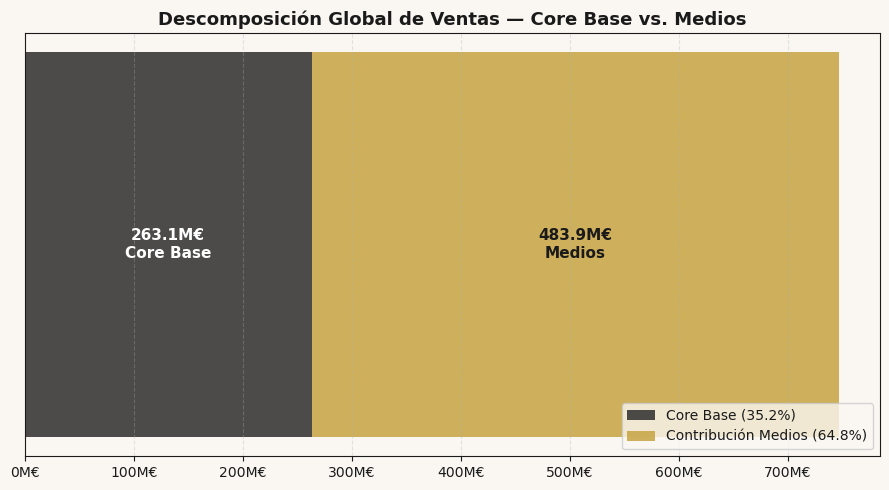

In [48]:
# ── 5.1 Waterfall — Core Base vs Medios (barra apilada horizontal) ───────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

categorias = ['Ventas\nModeladas']
ax.barh(categorias, [core_base_total], color=DARK, alpha=0.85,
        label=f'Core Base ({pct_core:.1f}%)')
ax.barh(categorias, [total_medios], left=[core_base_total], color=GOLD, alpha=0.9,
        label=f'Contribución Medios ({pct_medios:.1f}%)')

# Etiquetas
ax.text(core_base_total / 2, 0, f'{core_base_total/1e6:.1f}M€\nCore Base',
        ha='center', va='center', color='white', fontsize=11, fontweight='bold')
if total_medios > 0:
    ax.text(core_base_total + total_medios / 2, 0, f'{total_medios/1e6:.1f}M€\nMedios',
            ha='center', va='center', color=BLACK, fontsize=11, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M€'))
ax.set_title('Descomposición Global de Ventas — Core Base vs. Medios',
             fontsize=13, fontweight='bold', color=BLACK)
ax.legend(fontsize=10, loc='lower right')
ax.set_yticks([])
fig.tight_layout()
guardar_img('waterfall_core_vs_medios')
plt.show()

  Guardada: img/waterfall_descomposicion_v001.png


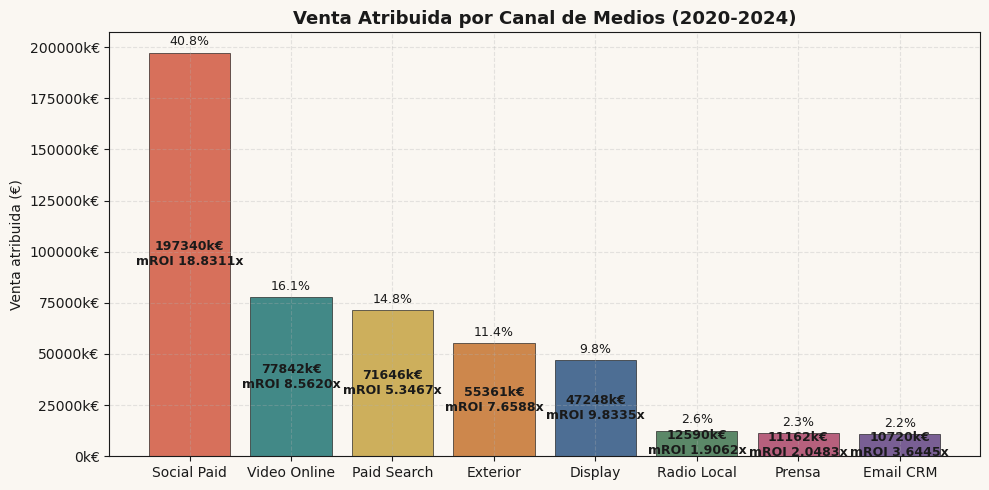

In [49]:
# ── 5.2 Waterfall canales activos ────────────────────────────────────────────
canales_activos_data = [(c, venta_atribuida[c]) for c in CANALES if betas_canales[c] > 0]
canales_activos_data.sort(key=lambda x: x[1], reverse=True)

nombres_act = [c for c, _ in canales_activos_data]
ventas_act  = [v for _, v in canales_activos_data]
colores_act = [CANAL_COLORS[c] for c in nombres_act]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

bars = ax.bar(nombres_act, ventas_act, color=colores_act, edgecolor=BLACK,
              linewidth=0.5, alpha=0.9)

for bar, val, canal in zip(bars, ventas_act, nombres_act):
    mid = bar.get_height() / 2
    ax.text(bar.get_x() + bar.get_width()/2, mid,
            f'{val/1e3:.0f}k€\nmROI {mroi[canal]:.4f}x',
            ha='center', va='center', fontsize=9, color=BLACK, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, val + max(ventas_act)*0.01,
            f'{peso_pct[canal]:.1f}%', ha='center', va='bottom', fontsize=9, color=BLACK)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
ax.set_title('Venta Atribuida por Canal de Medios (2020-2024)',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_ylabel('Venta atribuida (€)')
fig.tight_layout()
guardar_img('waterfall_descomposicion')
plt.show()

  Guardada: img/donut_atribucion_ventas_v001.png


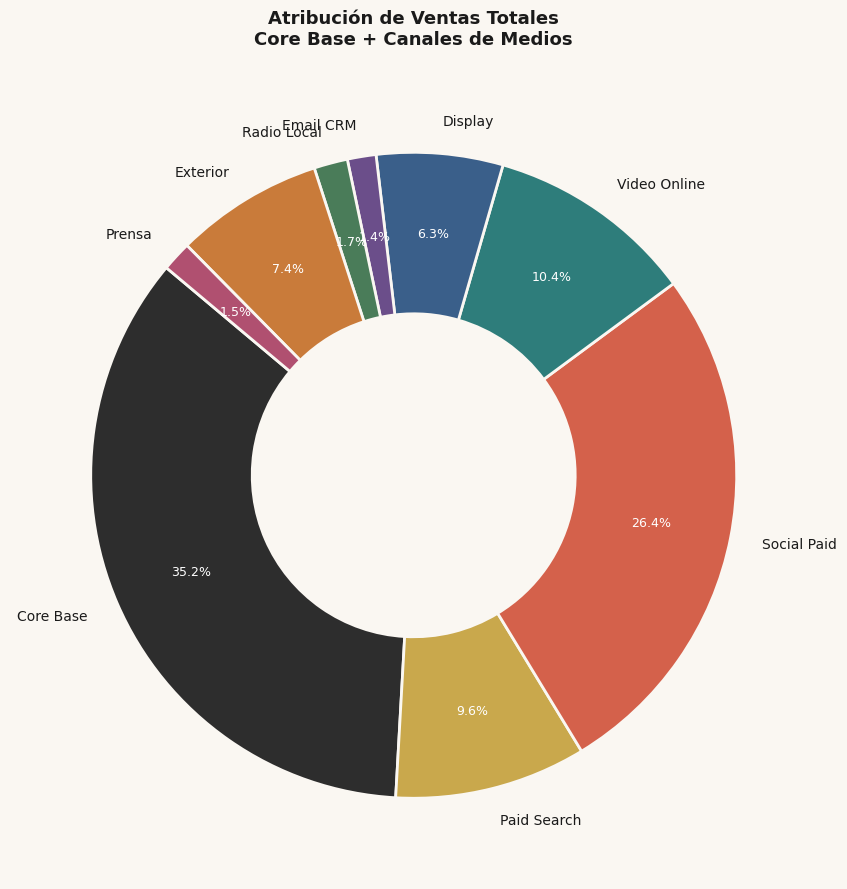

In [50]:
# ── 5.3 Donut: Core Base + canales activos ───────────────────────────────────
canales_pos = [(c, venta_atribuida[c]) for c in CANALES if venta_atribuida[c] > 0]
etiq_donut  = ['Core Base'] + [c for c, _ in canales_pos]
vals_donut  = [core_base_total] + [v for _, v in canales_pos]
cols_donut  = [DARK] + [CANAL_COLORS[c] for c, _ in canales_pos]

fig, ax = plt.subplots(figsize=(9, 9), facecolor=CREAM)
ax.set_facecolor(CREAM)

wedges, texts, autotexts = ax.pie(
    vals_donut,
    labels=etiq_donut,
    colors=cols_donut,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'width': 0.5, 'edgecolor': CREAM, 'linewidth': 2},
    pctdistance=0.75,
)
for t in texts:
    t.set_fontsize(10)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')

ax.set_title('Atribución de Ventas Totales\nCore Base + Canales de Medios',
             fontsize=13, fontweight='bold', color=BLACK, pad=20)
fig.tight_layout()
guardar_img('donut_atribucion_ventas')
plt.show()

## Bloque 6 — Mapa de Inversión y mROI

Comparación entre la inversión real por canal y el retorno marginal obtenido.

  Guardada: img/mroi_por_canal_v001.png


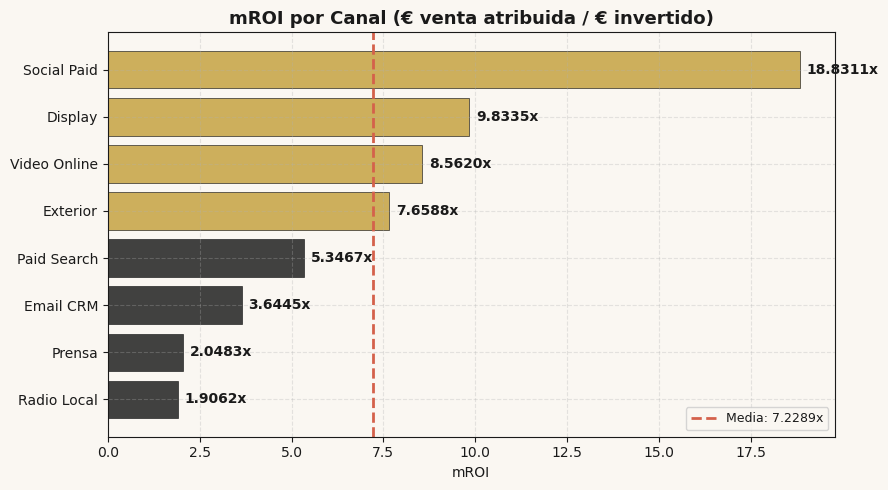

In [51]:
# ── 6.1 mROI por canal (canales activos) ─────────────────────────────────────
canales_mroi = [(c, mroi[c]) for c in CANALES if mroi[c] > 0]
canales_mroi.sort(key=lambda x: x[1])
nombres_mroi = [c for c, _ in canales_mroi]
vals_mroi    = [v for _, v in canales_mroi]
media_mroi   = np.mean(vals_mroi) if vals_mroi else 0

fig, ax = plt.subplots(figsize=(9, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

colores_m = [GOLD if v >= media_mroi else DARK for v in vals_mroi]
bars = ax.barh(nombres_mroi, vals_mroi, color=colores_m, edgecolor=BLACK, linewidth=0.5, alpha=0.9)

if media_mroi > 0:
    ax.axvline(media_mroi, color=CORAL, linewidth=2, linestyle='--',
               label=f'Media: {media_mroi:.4f}x')

for bar, val in zip(bars, vals_mroi):
    ax.text(val + max(vals_mroi)*0.01 if vals_mroi else 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}x', va='center', fontsize=10, color=BLACK, fontweight='bold')

ax.set_title('mROI por Canal (€ venta atribuida / € invertido)',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_xlabel('mROI')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('mroi_por_canal')
plt.show()

  Guardada: img/inversion_vs_atribuida_v001.png


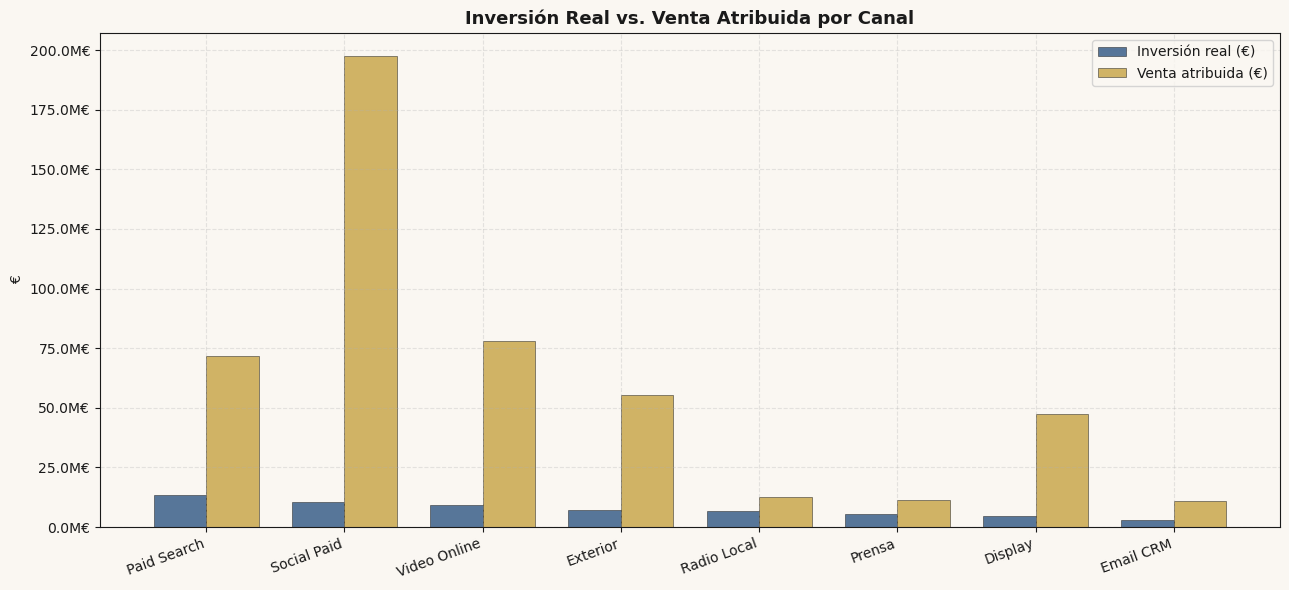

In [52]:
# ── 6.2 Inversión real vs Venta atribuida por canal ──────────────────────────
canales_ord2 = sorted(CANALES, key=lambda c: inv_real[c], reverse=True)
x = np.arange(len(canales_ord2))
w = 0.38

fig, ax = plt.subplots(figsize=(13, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.bar(x - w/2, [inv_real[c] for c in canales_ord2], width=w,
       color=BLUE, alpha=0.85, edgecolor=BLACK, linewidth=0.4, label='Inversión real (€)')
ax.bar(x + w/2, [venta_atribuida[c] for c in canales_ord2], width=w,
       color=GOLD, alpha=0.85, edgecolor=BLACK, linewidth=0.4, label='Venta atribuida (€)')

ax.set_xticks(x)
ax.set_xticklabels(canales_ord2, rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.set_title('Inversión Real vs. Venta Atribuida por Canal',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_ylabel('€')
ax.legend(fontsize=10)
fig.tight_layout()
guardar_img('inversion_vs_atribuida')
plt.show()

  Guardada: img/scatter_inversion_mroi_v001.png


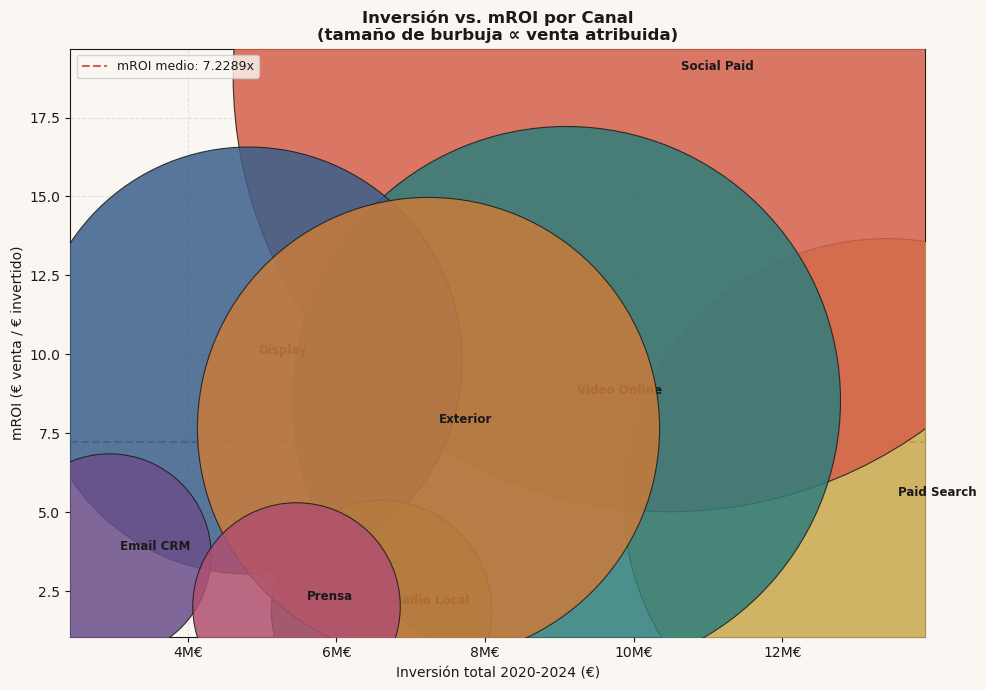

In [53]:
# ── 6.3 Scatter Inversión vs mROI (burbuja por venta atribuida) ──────────────
fig, ax = plt.subplots(figsize=(10, 7), facecolor=CREAM)
ax.set_facecolor(CREAM)

for canal in CANALES:
    inv_c  = inv_real[canal]
    mroi_c = mroi[canal]
    tam    = max(venta_atribuida[canal], 1e3)
    color  = CANAL_COLORS[canal]
    alpha  = 0.85 if mroi_c > 0 else 0.3
    ax.scatter(inv_c, mroi_c, s=tam/500, color=color, edgecolors=BLACK,
               linewidth=0.8, alpha=alpha, zorder=3)
    ax.annotate(canal, (inv_c, mroi_c),
                textcoords='offset points', xytext=(8, 4),
                fontsize=8.5, color=BLACK, fontweight='bold' if mroi_c > 0 else 'normal')

if media_mroi > 0:
    ax.axhline(media_mroi, color=CORAL, linewidth=1.5, linestyle='--',
               label=f'mROI medio: {media_mroi:.4f}x')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M€'))
ax.set_title('Inversión vs. mROI por Canal\n(tamaño de burbuja ∝ venta atribuida)',
             fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Inversión total 2020-2024 (€)')
ax.set_ylabel('mROI (€ venta / € invertido)')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('scatter_inversion_mroi')
plt.show()

  Guardada: img/mapa_inversion_pesos_v001.png


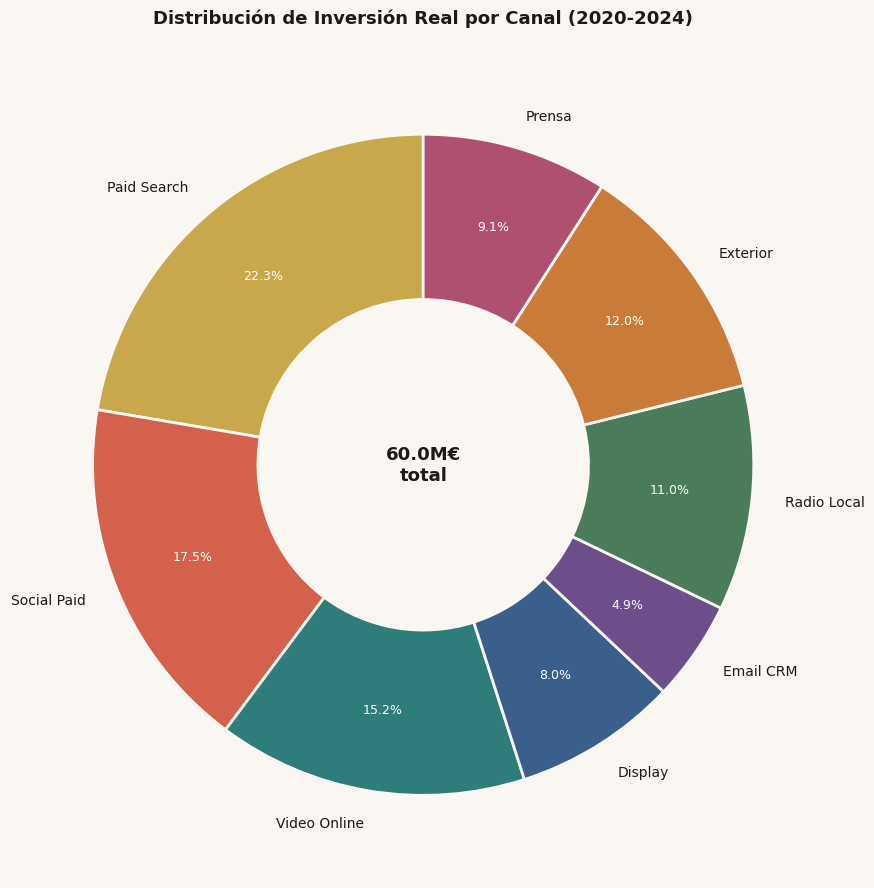

In [54]:
# ── 6.4 Distribución de la inversión real (donut) ────────────────────────────
inv_total = sum(inv_real.values())
nombres_inv = list(inv_real.keys())
vals_inv    = [inv_real[c] for c in nombres_inv]
colores_inv = [CANAL_COLORS[c] for c in nombres_inv]

fig, ax = plt.subplots(figsize=(9, 9), facecolor=CREAM)
ax.set_facecolor(CREAM)

wedges, texts, autotexts = ax.pie(
    vals_inv,
    labels=nombres_inv,
    colors=colores_inv,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.5, 'edgecolor': CREAM, 'linewidth': 2},
    pctdistance=0.75,
)
for t in texts:
    t.set_fontsize(10)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')

ax.text(0, 0, f'{inv_total/1e6:.1f}M€\ntotal', ha='center', va='center',
        fontsize=13, fontweight='bold', color=BLACK)
ax.set_title('Distribución de Inversión Real por Canal (2020-2024)',
             fontsize=13, fontweight='bold', color=BLACK, pad=20)
fig.tight_layout()
guardar_img('mapa_inversion_pesos')
plt.show()

## Bloque 7 — Tabla de Atribución Completa

Tabla maestra con todas las métricas de atribución por canal, exportada como CSV para uso en fases siguientes.

In [55]:
# ── Construir tabla ───────────────────────────────────────────────────────────
# Elasticidad marketing: %ΔY por %ΔX ⇒ β × X̄ / Ȳ (en escala adstock)
mean_y   = df_model['Yt'].mean()
elastic  = {c: (betas_canales[c] * df_model[ADSTOCK_MAP[c]].mean() / mean_y) for c in CANALES}

tabla_atribucion = pd.DataFrame({
    'Canal':              CANALES,
    'β_m':                [betas_canales[c] for c in CANALES],
    'Σ Adstock (€)':      [sum_adstock[c]   for c in CANALES],
    'Venta Atrib. (€)':   [venta_atribuida[c] for c in CANALES],
    'Peso % (medios)':    [peso_pct[c]        for c in CANALES],
    'Inversión real (€)': [inv_real[c]         for c in CANALES],
    'mROI':               [mroi[c]             for c in CANALES],
    'Elasticidad':        [elastic[c]          for c in CANALES],
    'Activo':             [betas_canales[c] > 0 for c in CANALES],
}).sort_values('mROI', ascending=False).reset_index(drop=True)

# Exportar
out_path = os.path.join(OUT_DIR, 'tabla_atribucion.csv')
tabla_atribucion.to_csv(out_path, index=False)
print(f'✓ tabla_atribucion.csv guardada en {out_path}')

# Mostrar formateada
tabla_fmt = tabla_atribucion.copy()
tabla_fmt['β_m']               = tabla_fmt['β_m'].map(lambda x: f'{x:.6f}')
tabla_fmt['Σ Adstock (€)']     = tabla_fmt['Σ Adstock (€)'].map(lambda x: f'{x:>14,.0f}€')
tabla_fmt['Venta Atrib. (€)']  = tabla_fmt['Venta Atrib. (€)'].map(lambda x: f'{x:>14,.0f}€')
tabla_fmt['Peso % (medios)']   = tabla_fmt['Peso % (medios)'].map(lambda x: f'{x:5.1f}%')
tabla_fmt['Inversión real (€)']= tabla_fmt['Inversión real (€)'].map(lambda x: f'{x:>14,.0f}€')
tabla_fmt['mROI']              = tabla_fmt['mROI'].map(lambda x: f'{x:.4f}x')
tabla_fmt['Elasticidad']       = tabla_fmt['Elasticidad'].map(lambda x: f'{x:.4f}')
tabla_fmt['Activo']            = tabla_fmt['Activo'].map(lambda x: '✓' if x else '✗')

print()
print(tabla_fmt.to_string(index=False))

✓ tabla_atribucion.csv guardada en /Users/ruben/Desktop/3º INGENIERÍA MATEMÁTICA/2ºCUATRI/INTELIGENCIA ARTIFICIAL/ENTREGA-MARKETING/ENTREGA/outputs/tabla_atribucion.csv

       Canal      β_m   Σ Adstock (€) Venta Atrib. (€) Peso % (medios) Inversión real (€)     mROI Elasticidad Activo
 Social Paid 5.759868     34,261,289€     197,340,500€           40.8%        10,479,480€ 18.8311x      0.2574      ✓
     Display 7.390092      6,393,419€      47,247,957€            9.8%         4,804,788€  9.8335x      0.0616      ✓
Video Online 3.052467     25,501,298€      77,841,861€           16.1%         9,091,590€  8.5620x      0.1015      ✓
    Exterior 3.107311     17,816,213€      55,360,521€           11.4%         7,228,392€  7.6588x      0.0722      ✓
 Paid Search 2.952943     24,262,702€      71,646,370€           14.8%        13,400,201€  5.3467x      0.0934      ✓
   Email CRM 2.013468      5,323,992€      10,719,687€            2.2%         2,941,359€  3.6445x      0.0140      ✓
  

  Guardada: img/heatmap_tabla_atribucion_v001.png


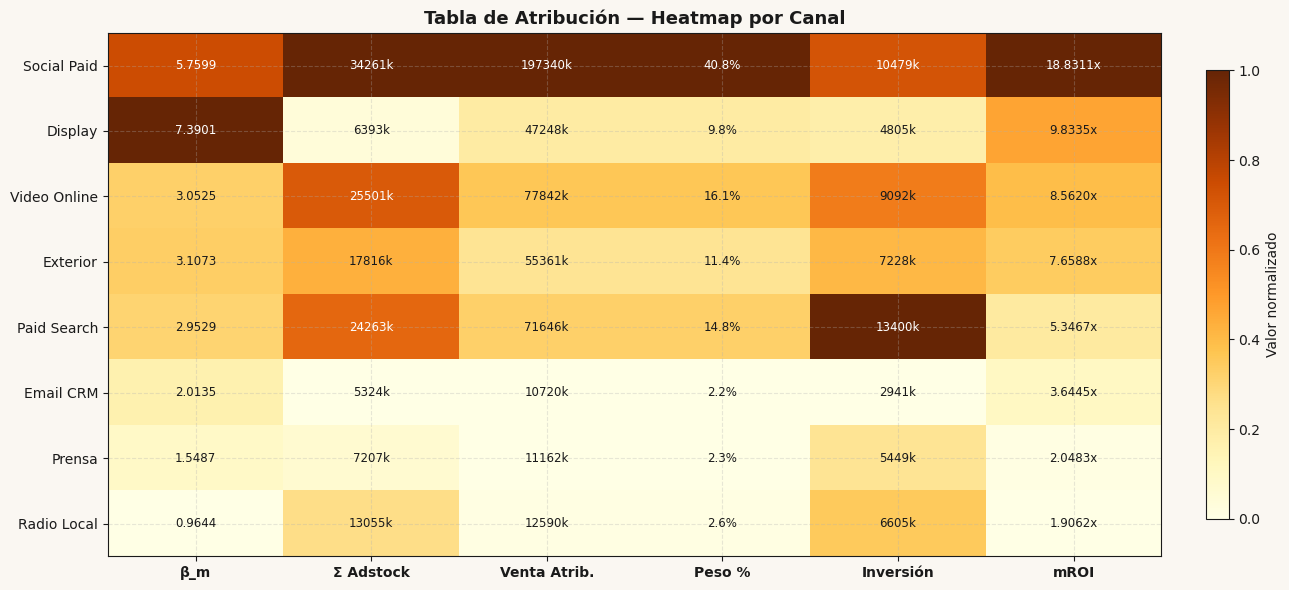

In [56]:
# ── 7.1 Heatmap tabla de atribución ──────────────────────────────────────────
cols_heat = ['β_m', 'Σ Adstock (€)', 'Venta Atrib. (€)', 'Peso % (medios)', 'Inversión real (€)', 'mROI']
heat_data = tabla_atribucion.set_index('Canal')[cols_heat]

# Normalizar por columna para el color
heat_norm = heat_data.copy()
for col in cols_heat:
    mn, mx = heat_norm[col].min(), heat_norm[col].max()
    heat_norm[col] = (heat_norm[col] - mn) / (mx - mn + 1e-10)

fig, ax = plt.subplots(figsize=(13, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

im = ax.imshow(heat_norm.values, cmap='YlOrBr', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(cols_heat)))
ax.set_xticklabels(['β_m', 'Σ Adstock', 'Venta Atrib.', 'Peso %', 'Inversión', 'mROI'],
                   fontsize=10, fontweight='bold')
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index, fontsize=10)

# Valores en celdas
for i, canal in enumerate(heat_data.index):
    for j, col in enumerate(cols_heat):
        val = heat_data.loc[canal, col]
        if col == 'β_m':
            txt = f'{val:.4f}'
        elif col in ('Σ Adstock (€)', 'Venta Atrib. (€)', 'Inversión real (€)'):
            txt = f'{val/1e3:.0f}k'
        elif col == 'Peso % (medios)':
            txt = f'{val:.1f}%'
        else:
            txt = f'{val:.4f}x'
        color_txt = 'white' if heat_norm.loc[canal, col] > 0.6 else BLACK
        ax.text(j, i, txt, ha='center', va='center', fontsize=8.5, color=color_txt)

ax.set_title('Tabla de Atribución — Heatmap por Canal',
             fontsize=13, fontweight='bold', color=BLACK)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04, label='Valor normalizado')
fig.tight_layout()
guardar_img('heatmap_tabla_atribucion')
plt.show()

## Bloque 7b — mROI Anual: Evolución de la Eficiencia de los Medios

El mROI global anual responde a: **¿cada año, por cada euro invertido en publicidad, cuántos euros de ventas se atribuyen a los medios?**  
A diferencia del mROI por canal (que es estático, calculado sobre todo el período), el mROI anual permite ver si la estrategia de medios gana o pierde eficiencia con el tiempo.  

> **Nota metodológica:** Los betas del modelo son fijos (estimados sobre 2020-2023). La variación anual del mROI proviene de cambios en la **inversión por canal** y en el **adstock acumulado** cada año, no de betas distintos.

In [57]:
# ── mROI anual: contribución y inversión año a año ─────────────────────────
df_model['anio'] = pd.to_datetime(df_model['semana_dt']).dt.year
df_inv_raw = pd.read_parquet(os.path.join(DATA_DIR, 'df_inversion_clean.parquet'))
df_inv_raw['anio'] = pd.to_datetime(df_inv_raw['semana_dt']).dt.year

ANIOS = sorted(df_model['anio'].unique())

registros = []
for anio in ANIOS:
    mask = df_model['anio'] == anio
    mask_inv = df_inv_raw['anio'] == anio
    contrib_total = 0
    inv_total     = 0
    detalle_anio  = {}
    for canal in CANALES:
        col     = ADSTOCK_MAP[canal]
        beta    = BETAS.get(ADSTOCK_MAP[canal], 0.0)
        adst    = df_model.loc[mask, col].sum()
        inv     = df_inv_raw.loc[mask_inv, canal].sum()
        contrib = beta * adst
        contrib_total += max(contrib, 0)
        inv_total     += inv
        detalle_anio[canal] = {'contrib': max(contrib,0), 'inv': inv}
    yt_real   = df_model.loc[mask, 'Yt'].sum()
    mroi_glob = contrib_total / inv_total if inv_total > 0 else 0
    registros.append({
        'anio'          : anio,
        'contrib_total' : contrib_total,
        'inv_total'     : inv_total,
        'yt_real'       : yt_real,
        'mroi_global'   : mroi_glob,
        'detalle'       : detalle_anio,
    })

df_mroi_anual = pd.DataFrame(registros)

print('mROI ANUAL GLOBAL')
print('=' * 70)
print(f'{"Año":<6} {"Inversión":>13} {"Contrib. medios":>16} {"Yt real":>13} {"mROI":>8}')
print('-' * 70)
for _, r in df_mroi_anual.iterrows():
    print(f'{int(r.anio):<6} {r.inv_total/1e6:>11.2f}M€ {r.contrib_total/1e6:>14.1f}M€ '
          f'{r.yt_real/1e6:>11.1f}M€ {r.mroi_global:>8.4f}x')
print('=' * 70)

mROI ANUAL GLOBAL
Año        Inversión  Contrib. medios       Yt real     mROI
----------------------------------------------------------------------
2020          7.20M€           55.7M€        92.1M€   7.7394x
2021         10.80M€           86.7M€       138.0M€   8.0290x
2022         12.60M€          101.9M€       160.9M€   8.0870x
2023         13.80M€          113.1M€       176.2M€   8.1938x
2024         15.60M€          126.5M€       199.6M€   8.1091x


  Guardada: img/mroi_anual_global_v001.png


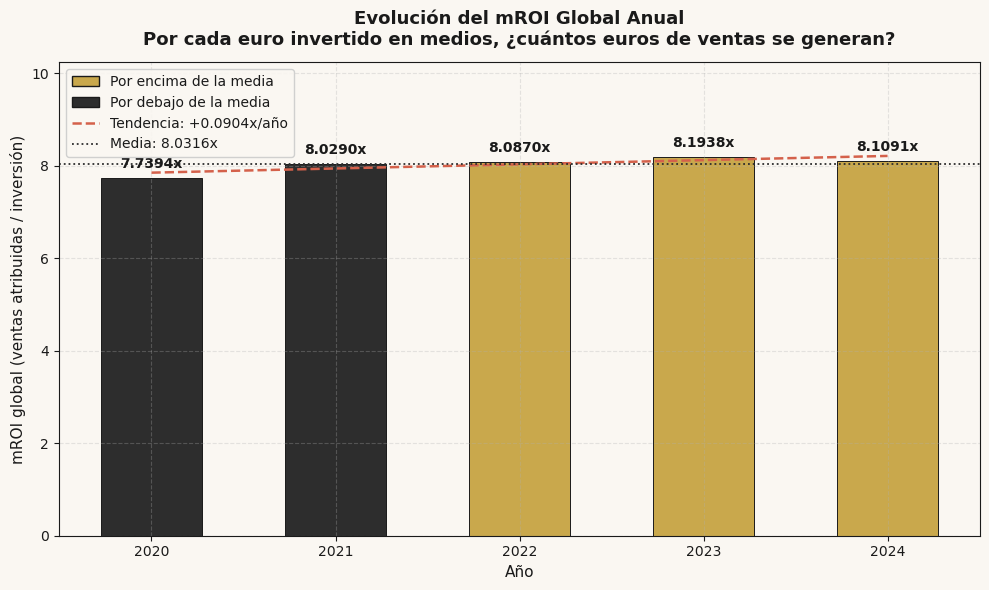

In [58]:
# ── 7b.1 mROI global anual (barras + línea de tendencia) ──────────────────
mroi_vals = df_mroi_anual['mroi_global'].values
anios     = df_mroi_anual['anio'].values
media_mroi = mroi_vals.mean()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

colores = [GOLD if v >= media_mroi else DARK for v in mroi_vals]
bars = ax.bar(anios, mroi_vals, color=colores,
              edgecolor=BLACK, linewidth=0.7, width=0.55)
ax.bar_label(bars, labels=[f'{v:.4f}x' for v in mroi_vals],
             padding=5, fontsize=10, fontweight='bold')

# Línea de tendencia
z = np.polyfit(anios, mroi_vals, 1)
ax.plot(anios, np.polyval(z, anios), '--',
        color=CORAL, linewidth=1.8, label=f'Tendencia: {z[0]:+.4f}x/año')
ax.axhline(media_mroi, color=DARK, linestyle=':', linewidth=1.3,
           label=f'Media: {media_mroi:.4f}x')

ax.set_xticks(anios)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('mROI global (ventas atribuidas / inversión)', fontsize=11)
ax.set_title('Evolución del mROI Global Anual\n'
             'Por cada euro invertido en medios, ¿cuántos euros de ventas se generan?',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, max(mroi_vals) * 1.25)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=GOLD, edgecolor=BLACK, label='Por encima de la media'),
    Patch(facecolor=DARK, edgecolor=BLACK, label='Por debajo de la media'),
    plt.Line2D([0],[0], color=CORAL, linestyle='--', lw=1.8, label=f'Tendencia: {z[0]:+.4f}x/año'),
    plt.Line2D([0],[0], color=DARK, linestyle=':', lw=1.3, label=f'Media: {media_mroi:.4f}x'),
], fontsize=10, framealpha=0.9)

plt.tight_layout()
guardar_img('mroi_anual_global')
plt.show()

  Guardada: img/mroi_contrib_anual_canal_v001.png


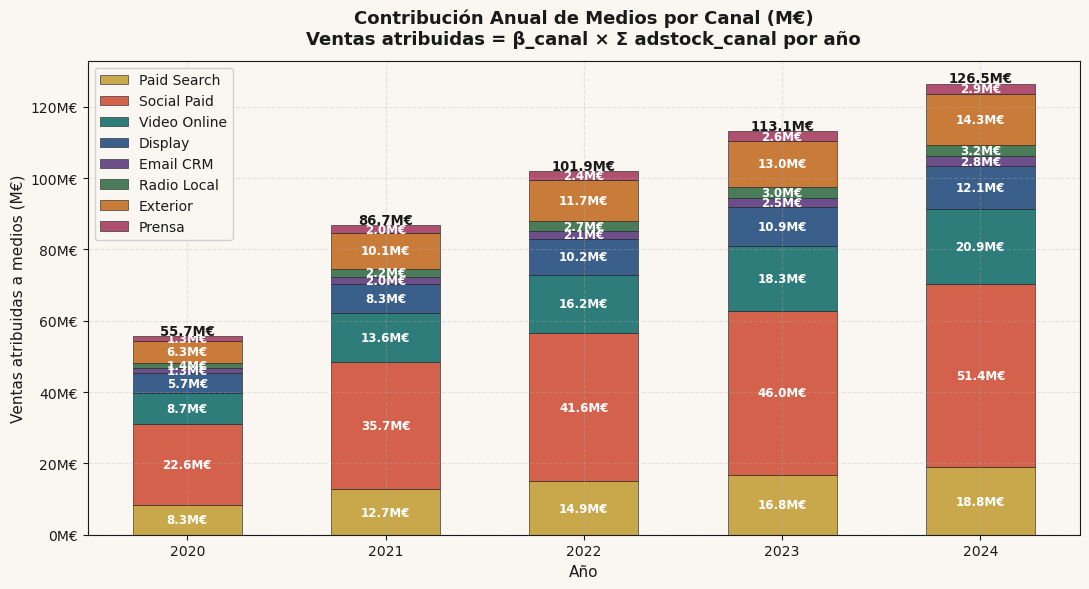

In [59]:
# ── 7b.2 Contribución anual por canal activo (barras apiladas) ─────────────
canales_activos_list = [c for c in CANALES if betas_canales[c] > 0]

contrib_matrix = pd.DataFrame(
    {canal: [r['detalle'][canal]['contrib']/1e6 for r in registros]
     for canal in canales_activos_list},
    index=anios
)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

bottom = np.zeros(len(anios))
for canal in canales_activos_list:
    vals = contrib_matrix[canal].values
    bars = ax.bar(anios, vals, bottom=bottom,
                  color=CANAL_COLORS[canal], edgecolor=BLACK,
                  linewidth=0.4, width=0.55, label=canal)
    for bar, v in zip(bars, vals):
        if v > 1.0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{v:.1f}M€', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bottom += vals

# Total encima de cada barra
for i, total in enumerate(contrib_matrix.sum(axis=1)):
    ax.text(anios[i], total + 0.3, f'{total:.1f}M€',
            ha='center', fontsize=9.5, fontweight='bold', color=BLACK)

ax.set_xticks(anios)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Ventas atribuidas a medios (M€)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M€'))
ax.set_title('Contribución Anual de Medios por Canal (M€)\n'
             'Ventas atribuidas = β_canal × Σ adstock_canal por año',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
guardar_img('mroi_contrib_anual_canal')
plt.show()

  Guardada: img/contrib_semanal_stackplot_v001.png


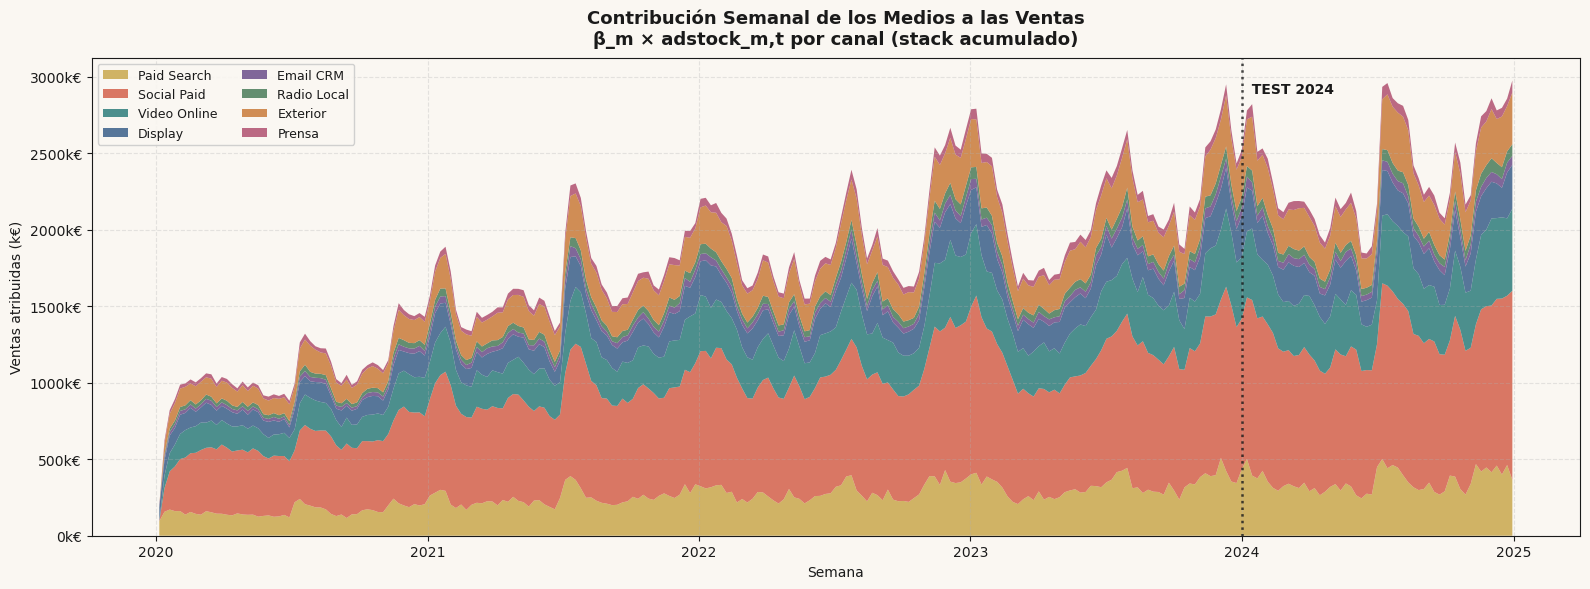

In [60]:
# ── 7b.4 Stackplot semanal: contribución de medios en el tiempo ──────────
canales_act = [c for c in CANALES if betas_canales[c] > 0]
fechas = pd.to_datetime(df_model['semana_dt']).values

contrib_semanal = {}
for canal in canales_act:
    col = ADSTOCK_MAP[canal]
    beta = BETAS.get(col, 0.0)
    contrib_semanal[canal] = (df_model[col].values * beta) / 1e3  # k€

fig, ax = plt.subplots(figsize=(16, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.stackplot(fechas,
             [contrib_semanal[c] for c in canales_act],
             labels=canales_act,
             colors=[CANAL_COLORS[c] for c in canales_act],
             alpha=0.85, edgecolor='none')

ax.axvline(CORTE_TEST, color=BLACK, linewidth=1.8, linestyle=':', alpha=0.8)
ax.text(CORTE_TEST, ax.get_ylim()[1]*0.95, '  TEST 2024', color=BLACK,
        fontsize=10, fontweight='bold', va='top')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.set_title('Contribución Semanal de los Medios a las Ventas\n'
             'β_m × adstock_m,t por canal (stack acumulado)',
             fontsize=13, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Semana')
ax.set_ylabel('Ventas atribuidas (k€)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2)
fig.tight_layout()
guardar_img('contrib_semanal_stackplot')
plt.show()


  Guardada: img/mroi_inversion_vs_contrib_anual_v001.png


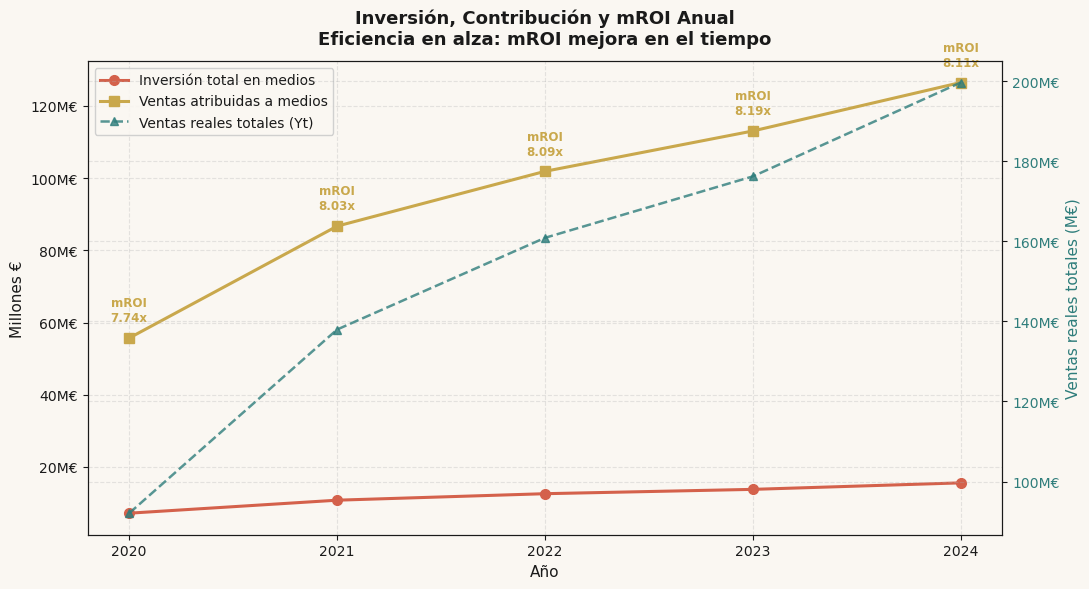

In [61]:
# ── 7b.3 Inversión vs Contribución vs Yt real — evolución anual ────────────
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

inv_vals    = df_mroi_anual['inv_total'].values    / 1e6
contrib_vals= df_mroi_anual['contrib_total'].values/ 1e6
yt_vals     = df_mroi_anual['yt_real'].values      / 1e6

ax.plot(anios, inv_vals, 'o-', color=CORAL,   linewidth=2.2,
        markersize=7, label='Inversión total en medios')
ax.plot(anios, contrib_vals, 's-', color=GOLD, linewidth=2.2,
        markersize=7, label='Ventas atribuidas a medios')

ax2 = ax.twinx()
ax2.plot(anios, yt_vals, '^--', color=TEAL, linewidth=1.8,
         markersize=6, label='Ventas reales totales (Yt)', alpha=0.8)
ax2.set_ylabel('Ventas reales totales (M€)', fontsize=11, color=TEAL)
ax2.tick_params(axis='y', labelcolor=TEAL)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M€'))

# Etiquetas de mROI encima de contrib
for anio, c, inv in zip(anios, contrib_vals, inv_vals):
    mroi_anio = c / inv
    ax.annotate(f'mROI\n{mroi_anio:.2f}x',
                xy=(anio, c), xytext=(0, 12),
                textcoords='offset points', ha='center',
                fontsize=8.5, color=GOLD, fontweight='bold')

ax.set_xticks(anios)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Millones €', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M€'))
ax.set_title('Inversión, Contribución y mROI Anual\n'
             f'{"Contribución crece con la inversión → mROI estable" if abs(contrib_vals[-1]/inv_vals[-1] - contrib_vals[0]/inv_vals[0]) < 0.02 else ("Eficiencia en alza: mROI mejora en el tiempo" if contrib_vals[-1]/inv_vals[-1] > contrib_vals[0]/inv_vals[0] else "Eficiencia en caída: mROI decrece en el tiempo")}',
             fontsize=13, fontweight='bold', pad=12)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
guardar_img('mroi_inversion_vs_contrib_anual')
plt.show()

## Bloque 8 — Verificaciones finales

In [62]:
# ── Checks ───────────────────────────────────────────────────────────────────
checks = []

# 1. Artefactos cargados
checks.append(('modelo, scaler y meta cargados', True))

# 2. Predicciones calculadas
checks.append(('Predicciones train+test calculadas',
               len(y_pred_train) == len(y_train) and len(y_pred_test) == len(y_test)))

# 3. Betas no negativos
checks.append(('β_m ≥ 0 para todos los canales',
               all(v >= 0 for v in betas_canales.values())))

# 4. Pesos suman ~100%
suma_pesos = sum(peso_pct.values())
checks.append((f'Pesos% suman ~100% (actual: {suma_pesos:.1f}%)',
               abs(suma_pesos - 100) < 1 or total_medios == 0))

# 5. tabla_atribucion.csv exportada
checks.append(('tabla_atribucion.csv exportada',
               os.path.exists(out_path)))

# 6. Canales activos coinciden con meta
activos_tabla = tabla_atribucion[tabla_atribucion['Activo'] == True]['Canal'].tolist()
checks.append((f'Canales activos = {CANALES_ACTIVOS}',
               set(activos_tabla) == set(CANALES_ACTIVOS)))

# 7. mROI ≥ 0
checks.append(('mROI ≥ 0 para todos los canales',
               all(v >= 0 for v in mroi.values())))

# 8. Imágenes generadas
imgs = [f for f in os.listdir(IMG_DIR) if f.endswith('.png')]
checks.append((f'Imágenes generadas en img/ ({len(imgs)} total)', len(imgs) > 0))

print('═' * 60)
print('  VERIFICACIONES FINALES — FASE 5')
print('═' * 60)
all_ok = True
for msg, ok in checks:
    estado = '✓' if ok else '✗'
    print(f'  {estado} {msg}')
    if not ok:
        all_ok = False
print('═' * 60)
print(f'  {"✓ FASE 5 COMPLETADA" if all_ok else "✗ Revisar checks fallidos"}')
print('═' * 60)

════════════════════════════════════════════════════════════
  VERIFICACIONES FINALES — FASE 5
════════════════════════════════════════════════════════════
  ✓ modelo, scaler y meta cargados
  ✓ Predicciones train+test calculadas
  ✓ β_m ≥ 0 para todos los canales
  ✓ Pesos% suman ~100% (actual: 100.0%)
  ✓ tabla_atribucion.csv exportada
  ✓ Canales activos = ['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Email CRM', 'Radio Local', 'Exterior', 'Prensa']
  ✓ mROI ≥ 0 para todos los canales
  ✓ Imágenes generadas en img/ (546 total)
════════════════════════════════════════════════════════════
  ✓ FASE 5 COMPLETADA
════════════════════════════════════════════════════════════
